In [18]:
import os
import sys
import time
import random
import yaml
import warnings
from pathlib import Path

import darkfield
import darkfield.mmmUtils_v2 as mu
import darkfield.rossendorfer_farbenliste as rofl

%load_ext autoreload
%autoreload 2

import sys, os
module_dir = "/home/yu79deg/darkfield_p5438/src"  # ← change if needed
if module_dir not in sys.path:
    sys.path.append(module_dir)

import darkfield.Gerchberg_saxton_aime as gs


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
# Inputs
figs_pickle = "/home/yu79deg/darkfield_p5438/Aime/pickles/GX_1_figs.pickle"
res_pickle  = "/home/yu79deg/darkfield_p5438/Aime/pickles/GX_1_res.pickle"

figs = mu.loadPickle(figs_pickle)
for i, key in enumerate(figs.keys(), 1):
    print(f"{i:2d}: {key}")




plane_keys = [
    "flow_017_-2.49_main",
    "flow_037_-1.89_main",
    "flow_057_-1.29_main",
    "flow_077_-0.69_main",
    "flow_097_-0.09_main",
    "flow_116_0.48_main",
    "flow_136_1.08_main",
    "flow_156_1.68_main",
    "flow_176_2.28_main",
    "flow_196_2.88_main",
]

photonenergy_eV = 8766.0
λ = 1.239841984e-6 / photonenergy_eV   # ≈ 1.415e-10 m
n = 1.0       # refractive index of medium


 1: beam_shaper_main
 2: CRL4a_main
 3: flow_000_-3.00_main
 4: flow_001_-2.97_main
 5: flow_002_-2.94_main
 6: flow_003_-2.91_main
 7: flow_004_-2.88_main
 8: flow_005_-2.85_main
 9: flow_006_-2.82_main
10: flow_007_-2.79_main
11: flow_008_-2.76_main
12: flow_009_-2.73_main
13: flow_010_-2.70_main
14: flow_011_-2.67_main
15: flow_012_-2.64_main
16: flow_013_-2.61_main
17: flow_014_-2.58_main
18: flow_015_-2.55_main
19: flow_016_-2.52_main
20: flow_017_-2.49_main
21: flow_018_-2.46_main
22: flow_019_-2.43_main
23: flow_020_-2.40_main
24: flow_021_-2.37_main
25: flow_022_-2.34_main
26: flow_023_-2.31_main
27: flow_024_-2.28_main
28: flow_025_-2.25_main
29: flow_026_-2.22_main
30: flow_027_-2.19_main
31: flow_028_-2.16_main
32: flow_029_-2.13_main
33: flow_030_-2.10_main
34: flow_031_-2.07_main
35: flow_032_-2.04_main
36: flow_033_-2.01_main
37: flow_034_-1.98_main
38: flow_035_-1.95_main
39: flow_036_-1.92_main
40: flow_037_-1.89_main
41: flow_038_-1.86_main
42: flow_039_-1.83_main
43: 

In [20]:
out = gs.benchmark_gs_with_lightpipes(
    figs_pickle_path=figs_pickle,
    res_pickle_path=res_pickle,              # can be None if you don’t want scaling
    plane_keys=plane_keys,
    wavelength=λ,
    n_medium=n,
    n_iterations=250,
    pad_factor=2,
    method="ER",                             # try "HIO" + smaller finishing ER pass later
    hio_beta=0.9,
    center_strategy="barycenter",
    use_gpu=False,
    compare_against_complex_fields=None,     # path to complex GT dict if you have it
)

E_ref = out["E_ref"]   # complex field at reference plane
dx = out["dx"]; dy = out["dy"]; zs = out["zs"]
print("E_ref shape:", E_ref.shape)


Chosen reference plane = 4


KeyboardInterrupt: 

In [16]:
for row in out["per_plane_metrics"]:
    print(f"{row['plane']:>24s}  z={row['z']:+.4e} m  corr={row['corr']:.4f}  RMSE={row['rmse']:.3e}  NRMSE={row['nrmse']:.3e}")

print("\nFinal GS avg RMSE across planes:",
      float(__import__("numpy").mean([r['rmse'] for r in out["per_plane_metrics"]])))


     flow_017_-2.49_main  z=-2.4900e+00 m  corr=0.0307  RMSE=6.308e+17  NRMSE=5.217e-01
     flow_037_-1.89_main  z=-1.8900e+00 m  corr=-0.0647  RMSE=1.029e+18  NRMSE=4.490e-01
     flow_057_-1.29_main  z=-1.2900e+00 m  corr=0.4760  RMSE=1.466e+18  NRMSE=2.816e-01
     flow_077_-0.69_main  z=-6.9000e-01 m  corr=0.5018  RMSE=3.048e+18  NRMSE=1.541e-01
     flow_097_-0.09_main  z=-9.0000e-02 m  corr=0.1990  RMSE=2.690e+19  NRMSE=1.868e-02
      flow_116_0.48_main  z=+4.8000e-01 m  corr=-0.0407  RMSE=4.903e+18  NRMSE=1.118e-01
      flow_136_1.08_main  z=+1.0800e+00 m  corr=0.0514  RMSE=2.045e+18  NRMSE=2.553e-01
      flow_156_1.68_main  z=+1.6800e+00 m  corr=0.0795  RMSE=1.199e+18  NRMSE=3.752e-01
      flow_176_2.28_main  z=+2.2800e+00 m  corr=0.0527  RMSE=7.667e+17  NRMSE=4.527e-01
      flow_196_2.88_main  z=+2.8800e+00 m  corr=-0.0198  RMSE=4.939e+17  NRMSE=5.754e-01

Final GS avg RMSE across planes: 4.2478857328457303e+18


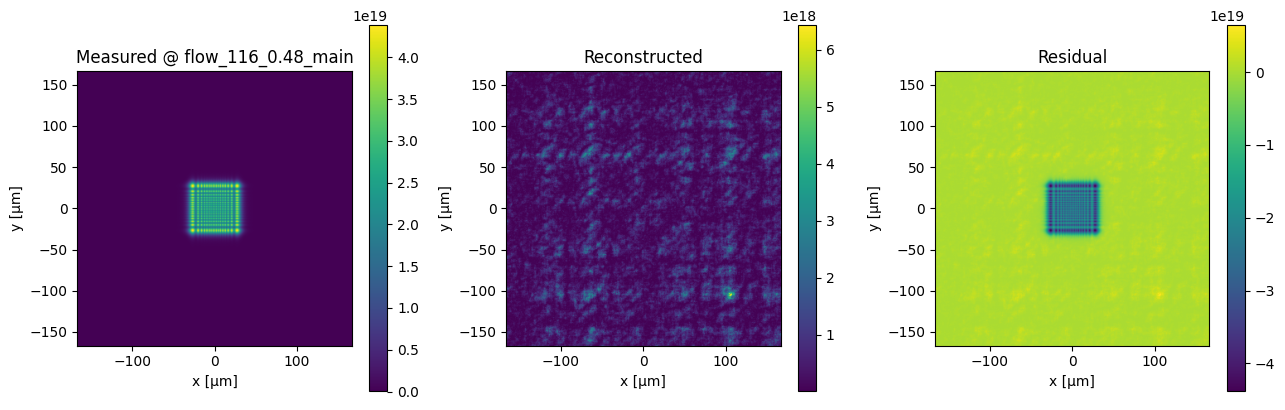

In [17]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open(figs_pickle, "rb") as f:
    figs = pickle.load(f)

k = plane_keys[5]  # choose the plane to visualize
data = figs[k]
img_meas = np.asarray(data[0], dtype=float)
box_m = float(data[2])
z_k = float(data[3])

# Rescale if you want photons scaling from _res.pickle
scale = 1.0
try:
    with open(res_pickle, "rb") as fr:
        res = pickle.load(fr); params = res[1]
        scale = float(params.get("scale_phot", 1.0))
except Exception:
    pass
I_meas = np.maximum(img_meas * scale, 0.0)

# Propagate reconstructed ref field to this plane
E_k = gs.angular_spectrum_propagate(E_ref, z=z_k - zs[np.argmin(np.abs(zs))],
                                    wavelength=λ, dx=dx, dy=dy, n=n, use_gpu=False)
I_rec = np.abs(E_k)**2

# Plots
extent_um = (-box_m/2*1e6, box_m/2*1e6, -box_m/2*1e6, box_m/2*1e6)
fig, axs = plt.subplots(1, 3, figsize=(13,4.2))
im0 = axs[0].imshow(I_meas, extent=extent_um, origin="lower"); axs[0].set_title(f"Measured @ {k}")
im1 = axs[1].imshow(I_rec,  extent=extent_um, origin="lower"); axs[1].set_title("Reconstructed")
im2 = axs[2].imshow(I_rec - I_meas, extent=extent_um, origin="lower"); axs[2].set_title("Residual")
for a in axs: a.set_xlabel("x [µm]"); a.set_ylabel("y [µm]")
fig.colorbar(im0, ax=axs[0]); fig.colorbar(im1, ax=axs[1]); fig.colorbar(im2, ax=axs[2])
plt.tight_layout(); plt.show()
